<div class="alert alert-block alert-success">
<b>Importacion de las librerias</b></div>


In [11]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Diccionario de las categorías
categorias = {
    0: "Árbol",
    1: "Suelo desnudo",
    2: "Pavimento",
    3: "Cuerpo de agua",
    4: "Techo de lámina",
    5: "Techo de losa",
    6: "Arbusto",
    7: "Hierba y pasto seco",
    8: "Hierba y pasto verde",
    9: "Sombra",
    10: "Sin etiqueta"
}


<div class="alert alert-block alert-success">
<b>Ruta de los archivos</b></div>


In [12]:
# Ruta a la carpeta donde están los archivos .csv que van a ser evaluados
ruta_carpeta = "/home/victor/Documents/prueba_modelos/predicciones_3_img_prueba_estrategias" 


# Lista de archivos etiquetados por el modelo
archivos_caract = [f for f in os.listdir(ruta_carpeta) if f.startswith("Caract_paralelo") and f.endswith("_con_estrategia5.csv")]

Procesando: image_x5_250

* Reporte de clases predichas erróneamente en 'image_x5_250':
--------------------------------------------------------
'Cuerpo de agua' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Sin etiqueta: 1 veces
   Total de errores para esta clase: 1

'Techo de losa' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Pavimento: 8 veces
   - Techo de lámina: 3 veces
   - Sombra: 8 veces
   - Sin etiqueta: 9 veces
   Total de errores para esta clase: 28

'Hierba y pasto seco' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 9 veces
   - Sin etiqueta: 8 veces
   Total de errores para esta clase: 17



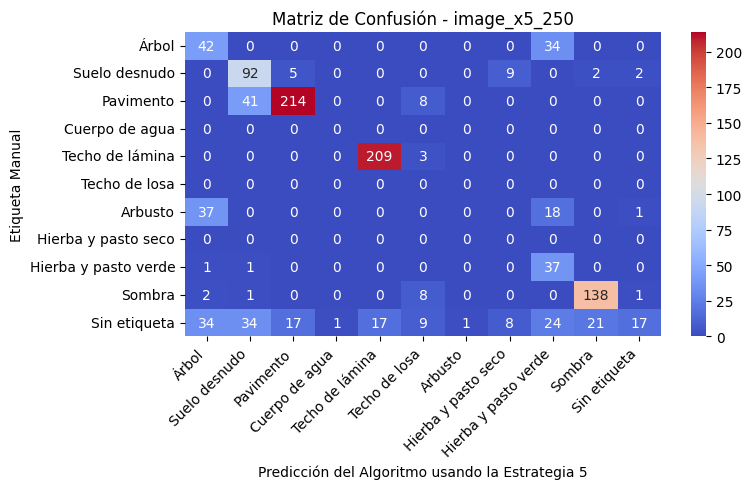

Procesando: image_x5_1730

* Reporte de clases predichas erróneamente en 'image_x5_1730':
--------------------------------------------------------
'Techo de lámina' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 1 veces
   - Sin etiqueta: 1 veces
   Total de errores para esta clase: 2

'Techo de losa' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Cuerpo de agua: 1 veces
   - Sombra: 3 veces
   Total de errores para esta clase: 4

'Hierba y pasto seco' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 3 veces
   - Cuerpo de agua: 1 veces
   - Sin etiqueta: 6 veces
   Total de errores para esta clase: 10

Clases ausentes en ambos archivos:
 - Pavimento


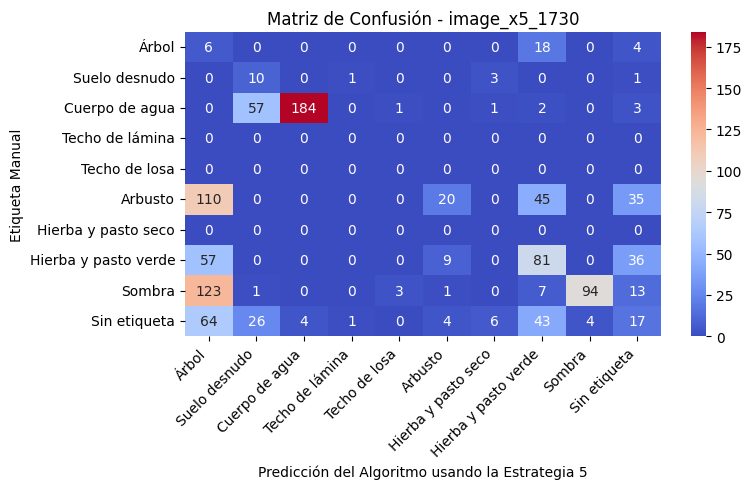

Procesando: image_x5_1272

* Reporte de clases predichas erróneamente en 'image_x5_1272':
--------------------------------------------------------
'Hierba y pasto seco' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Sin etiqueta: 1 veces
   Total de errores para esta clase: 1

'Sombra' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Árbol: 3 veces
   - Suelo desnudo: 8 veces
   - Pavimento: 10 veces
   - Arbusto: 3 veces
   - Hierba y pasto verde: 7 veces
   - Sin etiqueta: 62 veces
   Total de errores para esta clase: 93

Clases ausentes en ambos archivos:
 - Cuerpo de agua


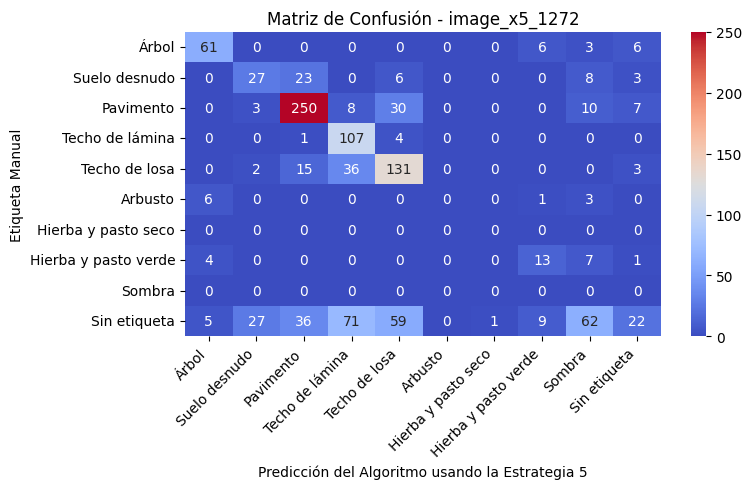

In [ ]:

# Listas para almacenar resultados de precisión y errores por imagen
resumen_errores_imagen = []

# =========================================================
# Lista para almacenar TP, FP, FN, TN y soporte por imagen y por clase
# =========================================================
resultados_detalle_confusion = []
metricas_globales_img= []
# =============================


# Procesar cada imagen seleccionada
for archivo_modelo in archivos_caract:
    nombre_image = archivo_modelo.replace("Caract_paralelo_", "").replace("_con_estrategia5.csv", "")
    archivo_etiquetado = f"Etiquetado_{nombre_image}.csv"

    ruta_modelo = os.path.join(ruta_carpeta, archivo_modelo)
    ruta_manual = os.path.join(ruta_carpeta, archivo_etiquetado)

    if not os.path.exists(ruta_manual):
        print(f" No encontrado el etiquetado manual para: {nombre_image}")
        continue

    print(f"Procesando: {nombre_image}")

    # Cargar las predicciones del modelo y el etiquetado manual
    df_caract = pd.read_csv(ruta_modelo, usecols=["indice", "prediction_actual_estrategia5"])
    df_etiquetado = pd.read_csv(ruta_manual, usecols=["indice", "categoria"])


    # Unir por índice
    df_comparacion = df_etiquetado.merge(df_caract, on="indice", how="left")


    # ==========================
    # Definir clases presentes
    # ==========================

    clases_etiquetadas = set(df_comparacion["categoria"].unique())
    clases_predichas = set(df_comparacion["prediction_actual_estrategia5"].unique())
    clases_en_ambos = sorted(clases_etiquetadas.union(clases_predichas))

    # Identificar clases ausentes en ambos archivos
    clases_no_aparecen = []
    clases_a_graficar = []
    
    clases_a_graficar =[]

    for c in categorias.keys():              
        esta_en_etiquetas = c in clases_etiquetadas
        esta_en_predicciones = c in clases_predichas
        if not esta_en_etiquetas and not esta_en_predicciones:
            clases_no_aparecen.append(categorias[c])
        else:
            clases_a_graficar.append(c)

    # ==========================
    # Calcular matriz de confusión
    # ==========================
    
    y_true= df_comparacion["categoria"].values
    y_pred= df_comparacion["prediction_actual_estrategia5"].values

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=clases_a_graficar
    )

    etiquetas_mapeadas = [categorias[c] for c in clases_a_graficar]
    
    # cm es una matriz KxK donde:
    # filas    = clases reales     (Etiqueta_Manual)
    # columnas = clases predichas  (Prediccion_Algoritmo)

    total_pixeles = cm.sum()  # total de superpíxeles considerados en esta imagen

    # ==========================
    # Calcular TP, FP, FN, TN y soporte por clase
    # ==========================
    sum_support = sum_p_weighted = sum_r_weighted = sum_f1_weighted = sum_support_f1= 0.0

    for idx, clase in enumerate(clases_a_graficar):
        nombre_clase = categorias[clase]
                
        # ACTUAL POR CHAT:
        
        tp = cm[idx, idx]           # diagonal
        fp = cm[:, idx].sum() - tp  # columna clase - tp
        fn = cm[idx, :].sum() - tp  # fila clase - tp
        tn = total_pixeles - tp - fp - fn     # todo lo demás
        
        support = tp + fn   # nº de ejemplos reales de esta clase

        if support > 0:
            # Hay ejemplos reales de la clase (caso 1 o 2)

            # metricas
            if tp > 0:
                precision = tp / (tp + fp)
                recall= tp / (tp + fn)
                f1_score = 2 * ( (precision * recall)/ (precision +recall))
            else:
                # Caso 2: hay etiquetas reales, pero nunca se predijo la clase, es decir TP=0
                precision = 0.0
                recall = 0.0
                f1_score = np.nan
            

            # Acumular para weighted (solo clases con soporte>0)
            # Para P y R sí usamos siempre support
            sum_support += support
            sum_p_weighted += support * precision
            sum_r_weighted += support * recall

            # Acumular para weighted F1 SOLO si F1 está definida
            if not np.isnan(f1_score):
                sum_f1_weighted += support * f1_score
                sum_support_f1  += support

        else:
            # support == 0,   casos 3 
            if (tp + fp) > 0:
                # CASO 3: No en etiquetas, Sí en predicción
                precision = 0.0
                recall = np.nan
                f1_score= np.nan
            else:
                # CASO 4: No en etiquetas, No en predicción
                precision = np.nan
                recall = np.nan
                f1_score = np.nan
            # No se acumula nada en los weighted
    
        support = cm[idx, :].sum()            # = tp + fn = nº reales de esa clase

        resultados_detalle_confusion.append({
            "Imagen": nombre_image,
            "Clase_ID": clase,
            "Clase_nombre": nombre_clase,
            "TP": int(tp),
            "FP": int(fp),
            "FN": int(fn),
            "TN": int(tn),
            "support": int(support),
            "Pre.": precision,
            "Rec.": recall, 
            "F1": f1_score,
            "total_pixeles_imagen": int(total_pixeles)
        })
        
    # ==========================
    # Reporte de errores (Caso 3)
    # ==========================
    errores_predicciones = []

    print(f"\n* Reporte de clases predichas erróneamente en '{nombre_image}':")
    print("--------------------------------------------------------")

    for clase_predicha in categorias.keys():

        nombre_clase = categorias[clase_predicha]

        fue_predicha = (df_comparacion["prediction_actual_estrategia5"] == clase_predicha).any()
        existe_en_verdaderas = (df_comparacion["categoria"] == clase_predicha).any()

        if fue_predicha and not existe_en_verdaderas:
            errores_df = df_comparacion[df_comparacion["prediction_actual_estrategia5"] == clase_predicha]
            conteo_confusiones = errores_df["categoria"].value_counts().sort_index()

            print(f"'{nombre_clase}' fue predicha pero nunca estuvo en etiquetas reales.")
            print("   Se confundió con:")
            for clase_real, conteo in conteo_confusiones.items():
                nombre_real = categorias.get(int(clase_real), "Desconocida")
                print(f"   - {nombre_real}: {conteo} veces")
            print(f"   Total de errores para esta clase: {len(errores_df)}\n")

            errores_predicciones.append({
                "Clase_predicha": nombre_clase,
                "ID": clase_predicha,
                "Total_errores": len(errores_df),
                "Confusiones": dict(conteo_confusiones.map(int))
            })

    # Caso 4: ausentes en ambos
    if clases_no_aparecen:
        print("Clases ausentes en ambos archivos:")
        for clase_nombre in clases_no_aparecen:
            print(f" - {clase_nombre}")

    total_errores_imagen = sum(e["Total_errores"] for e in errores_predicciones)
    resumen_errores_imagen.append({
        "Imagen": nombre_image,
        "Errores_totales_predichos_erróneamente": total_errores_imagen,
        "Clases_ausentes": clases_no_aparecen
    })
 
    # ==========================
    # Gráfico de matriz de confusión
    # ==========================

    plt.figure(figsize=(8, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm",
                xticklabels=etiquetas_mapeadas,
                yticklabels=etiquetas_mapeadas)
    plt.xlabel("Predicción del Algoritmo usando la Estrategia 5")
    plt.ylabel("Etiqueta Manual")
    plt.title(f"Matriz de Confusión - {nombre_image}")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

        
        
    # ---- Métricas globales weighted por imagen ----
    if sum_support > 0:
        weighted_p = (sum_p_weighted / sum_support) * 100
        weighted_r = (sum_r_weighted / sum_support) * 100
    else:
        weighted_p = np.nan
        weighted_r = np.nan

    if sum_support_f1 > 0:
        weighted_f1 = (sum_f1_weighted / sum_support_f1) * 100
    else:
        weighted_f1 = np.nan

    metricas_globales_img.append({
        "Imagen": nombre_image,
        "Pre_w": weighted_p,
        "Rec_w": weighted_r,
        "F1_w": weighted_f1
    })
    

# =========================================================
# DataFrame final con TP, FP, FN, TN, soporte por imagen y clase, precision, recall, f1-score
# =========================================================
df_detalle_confusion = pd.DataFrame(resultados_detalle_confusion)
df_metricas_globales_img = pd.DataFrame(metricas_globales_img)
df_errores = pd.DataFrame(resumen_errores_imagen)
    


In [14]:
df_detalle_confusion

,Imagen,Clase_ID,Clase_nombre,TP,FP,FN,TN,support,Pre.,Rec.,F1,total_pixeles_imagen
0,image_x5_250,0,Árbol,42,74,34,939,76,0.362069,0.552632,0.437500,1089
1,image_x5_250,1,Suelo desnudo,92,77,18,902,110,0.544379,0.836364,0.659498,1089
2,image_x5_250,2,Pavimento,214,22,49,804,263,0.906780,0.813688,0.857715,1089
3,image_x5_250,3,Cuerpo de agua,0,1,0,1088,0,0.000000,NaN,NaN,1089
4,image_x5_250,4,Techo de lámina,209,17,3,860,212,0.924779,0.985849,0.954338,1089
5,image_x5_250,5,Techo de losa,0,28,0,1061,0,0.000000,NaN,NaN,1089
6,image_x5_250,6,Arbusto,0,1,56,1032,56,0.000000,0.000000,NaN,1089
7,image_x5_250,7,Hierba y pasto seco,0,17,0,1072,0,0.000000,NaN,NaN,1089
8,image_x5_250,8,Hierba y pasto verde,37,76,2,974,39,0.327434,0.948718,0.486842,1089
9,image_x5_250,9,Sombra,138,23,12,916,150,0.857143,0.920000,0.887460,1089


In [ ]:
# Convertir precisiones por clase a porcentaje
df_detalle_confusion["Pre_w"] = df_detalle_confusion["Pre."] * 100.0

tabla_prec = (
    df_detalle_confusion
        .pivot(index="Imagen", columns="Clase_ID", values="Pre_w")
        .rename(columns=categorias)
)

tabla_prec = (
    df_metricas_globales_img
        .set_index("Imagen")[["Pre_w"]]
        .join(tabla_prec, how="left")
)
tabla_prec

,Pre_w,Árbol,Suelo desnudo,Pavimento,Cuerpo de agua,Techo de lámina,Techo de losa,Arbusto,Hierba y pasto seco,Hierba y pasto verde,Sombra,Sin etiqueta
Imagen,,,,,,,,,,,,
image_x5_250,74.510491,36.206897,54.437870,90.677966,0.00000,92.477876,0.000000,0.000000,0.0,32.743363,85.714286,80.952381
image_x5_1730,64.148222,1.666667,10.638298,NaN,97.87234,0.000000,0.000000,58.823529,0.0,41.326531,95.918367,15.596330
image_x5_1272,60.653115,80.263158,45.762712,76.923077,NaN,48.198198,56.956522,0.000000,0.0,44.827586,0.000000,52.380952


In [ ]:
# Convertir precisiones por clase a porcentaje
df_detalle_confusion["Rec_w"] = df_detalle_confusion["Rec."] * 100.0


tabla_recall = (
    df_detalle_confusion
        .pivot(index="Imagen", columns="Clase_ID", values="Rec_w")
        .rename(columns=categorias)
)

tabla_recall = (
    df_metricas_globales_img
        .set_index("Imagen")[["Rec_w"]]
        .join(tabla_recall, how="left")
)
tabla_recall


,Rec_w,Árbol,Suelo desnudo,Pavimento,Cuerpo de agua,Techo de lámina,Techo de losa,Arbusto,Hierba y pasto seco,Hierba y pasto verde,Sombra,Sin etiqueta
Imagen,,,,,,,,,,,,
image_x5_250,68.778696,55.263158,83.636364,81.368821,NaN,98.584906,NaN,0.00000,NaN,94.871795,92.000000,9.289617
image_x5_1730,37.625571,21.428571,66.666667,NaN,74.193548,NaN,NaN,9.52381,NaN,44.262295,38.842975,10.059172
image_x5_1272,56.731662,80.263158,40.298507,81.168831,NaN,95.535714,70.053476,0.00000,NaN,52.000000,NaN,7.534247


In [ ]:
# 1) Convertir F1 por clase a porcentaje (nuevo nombre)
df_detalle_confusion["F1_w"] = df_detalle_confusion["F1"] * 100.0

# 2) Tabla ancha por imagen x clase, usando F1_pct
tabla_f1 = (
    df_detalle_confusion
        .pivot(index="Imagen", columns="Clase_ID", values="F1_w")
        .rename(columns=categorias)
)

# 3) Añadir F1_w (weighted por imagen) a la izquierda
tabla_f1 = (
    df_metricas_globales_img
        .set_index("Imagen")[["F1_w"]]   
        .join(tabla_f1, how="left")
)

tabla_f1


,F1_w,Árbol,Suelo desnudo,Pavimento,Cuerpo de agua,Techo de lámina,Techo de losa,Arbusto,Hierba y pasto seco,Hierba y pasto verde,Sombra,Sin etiqueta
Imagen,,,,,,,,,,,,
image_x5_250,69.341666,43.750000,65.949821,85.771543,NaN,95.433790,NaN,NaN,NaN,48.684211,88.745981,16.666667
image_x5_1730,43.841833,3.092784,18.348624,NaN,84.40367,NaN,NaN,16.393443,NaN,42.744063,55.294118,12.230216
image_x5_1272,53.679139,80.263158,42.857143,78.988942,NaN,64.071856,62.829736,NaN,NaN,48.148148,NaN,13.173653


In [18]:
df_errores


,Imagen,Errores_totales_predichos_erróneamente,Clases_ausentes
0,image_x5_250,46,[]
1,image_x5_1730,16,[Pavimento]
2,image_x5_1272,94,[Cuerpo de agua]


# METRICAS POR CLASE PARA LAS 3 IMG

In [19]:
# df_detalle_confusion contiene por imagen y clase:
# Imagen, Clase_ID, Clase_nombre, TP, FP, FN, TN, support, Pre., Rec., F1, total_pixeles_imagen

filas_global_clase = []

sum_support      = 0.0   # para weighted P y R
sum_p_weighted   = 0.0
sum_r_weighted   = 0.0

sum_support_f1   = 0.0   # para weighted F1 solo donde F1 está definida
sum_f1_weighted  = 0.0

for clase_id, nombre_clase in categorias.items():
    # Agrupar los conteos de esta clase en TODAS las imágenes
    df_c = df_detalle_confusion[df_detalle_confusion["Clase_ID"] == clase_id]

    tp = df_c["TP"].sum()
    fp = df_c["FP"].sum()
    fn = df_c["FN"].sum()
    support = df_c["support"].sum()   # ejemplos reales de esta clase en todo el conjunto

    # ----- Lógica de casos 1–4 global -----
    if support > 0:
        # Caso 1 o 2 global
        if tp > 0:
            precision = tp / (tp + fp)
            recall    = tp / (tp + fn)
            f1_score  = 2 * (precision * recall) / (precision + recall)
        else:
            # Caso 2: hay etiquetas reales, pero nunca se predijo correctamente
            precision = 0.0
            recall    = 0.0
            f1_score  = np.nan

        # Acumular para weighted P y R
        sum_support    += support
        sum_p_weighted += support * precision
        sum_r_weighted += support * recall

        # Acumular para weighted F1 solo si está definida
        if not np.isnan(f1_score):
            sum_f1_weighted += support * f1_score
            sum_support_f1  += support

    else:
        # support == 0 → caso 3 o 4 global
        if (tp + fp) > 0:
            # Caso 3 global: se predijo pero nunca estuvo en etiquetas
            precision = 0.0
            recall    = np.nan
            f1_score  = np.nan
        else:
            # Caso 4 global: nunca apareció en etiquetas ni en predicciones
            precision = np.nan
            recall    = np.nan
            f1_score  = np.nan

    filas_global_clase.append({
        "Clase_ID":    clase_id,
        "Clase_nombre": nombre_clase,
        "TP_global":   int(tp),
        "FP_global":   int(fp),
        "FN_global":   int(fn),
        "support_global": int(support),
        "Pre_global":  precision * 100 if not np.isnan(precision) else np.nan,
        "Rec_global":  recall    * 100 if not np.isnan(recall)    else np.nan,
        "F1_global":   f1_score  * 100 if not np.isnan(f1_score)  else np.nan,
    })

df_metricas_globales_clase = pd.DataFrame(filas_global_clase)
df_metricas_globales_clase


,Clase_ID,Clase_nombre,TP_global,FP_global,FN_global,support_global,Pre_global,Rec_global,F1_global
0,0,Árbol,109,443,71,180,19.746377,60.555556,29.781421
1,1,Suelo desnudo,129,193,63,192,40.062112,67.187500,50.194553
2,2,Pavimento,464,97,107,571,82.709447,81.260946,81.978799
3,3,Cuerpo de agua,184,5,64,248,97.354497,74.193548,84.210526
4,4,Techo de lámina,316,134,8,324,70.222222,97.530864,81.653747
5,5,Techo de losa,131,131,56,187,50.000000,70.053476,58.351893
6,6,Arbusto,20,15,256,276,57.142857,7.246377,12.861736
7,7,Hierba y pasto seco,0,28,0,0,0.000000,NaN,NaN
8,8,Hierba y pasto verde,131,207,116,247,38.757396,53.036437,44.786325
9,9,Sombra,232,120,160,392,65.909091,59.183673,62.365591


In [20]:
if sum_support > 0:
    Pre_w_global = (sum_p_weighted  / sum_support) * 100
    Rec_w_global = (sum_r_weighted  / sum_support) * 100
else:
    Pre_w_global = np.nan
    Rec_w_global = np.nan

if sum_support_f1 > 0:
    F1_w_global  = (sum_f1_weighted / sum_support_f1) * 100
else:
    F1_w_global  = np.nan

metricas_globales_totales = {
    "Pre_w_global": Pre_w_global,
    "Rec_w_global": Rec_w_global,
    "F1_w_global":  F1_w_global
}

print(metricas_globales_totales)


{'Pre_w_global': np.float64(57.30377004027242), 'Rec_w_global': np.float64(54.33915976694266), 'F1_w_global': np.float64(51.50515831637637)}
